Реализация адаптивных и стохастических методов $AdaGrad, AdamW$.
Подходы к борьбе с переобучением (отложенная выборка, кросс-валидация, регуляризации L1, L2):
- Отложенная выборка (Hold-out Validation): Техника однократного разделения исходного множества на изолированные подмножества (например, Train и Test). Если тестовое подмножество используется исключительно для финальной фиксации метрики, процедура корректна. Если же по отложенной выборке подбираются гиперпараметры ($\lambda$) или принимается решение о досрочной остановке (Early Stopping), для предотвращения утечки данных (data leakage) требуется трехкомпонентное разбиение: Train (обучение), Validation (настройка $\lambda$, Early Stopping) и Test (финальный аудит).
- Кросс-валидация (K-Fold Cross-Validation): Циклическое разбиение данных на $K$ равных блоков (фолдов). На каждой из $K$ итераций модель обучается на $K-1$ блоках, а тестируется на оставшемся одном. Метод минимизирует дисперсию оценки качества модели при малом объеме выборки.

Для сопоставимости силы штрафа при изменении объема выборки $N$, регуляризационные члены нормируются на размер данных:
L1-регуляризация (аппроксимация Lasso подградиентным методом):
$$ J_{L1} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}i)^2 + \frac{\lambda}{N} \sum{j=1}^M |w_j| $$
L2-регуляризация (Ridge-регрессия):
$$ J_{L2} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}i)^2 + \frac{\lambda}{N} \sum{j=1}^M w_j^2 $$
Где $N$ — количество объектов, $M$ — количество признаков, а вектор весов $w$ не включает в себя свободный член (bias).

## *AdaGrad* (Adaptive Gradient Algorithm)
- Суть: Алгоритм адаптирует темп обучения покоординатно, масштабируя текущий градиент обратно пропорционально корню из суммы квадратов всех исторических градиентов данного параметра. Это позволяет делать большие шаги по редким (разреженным) признакам и уменьшать шаг по часто обновляемым.

Математический шаг оптимизации:
Пусть $g_t = \nabla_{\theta} L(\theta_t)$ — градиент функции потерь по весам $\theta$ на шаге $t$. Аккумуляция квадратов градиентов $G_t \in \mathbb{R}^d$ и обновление параметров выполняются покоординатно (оператор $\odot$ обозначает умножение Адамара):
$$ G_t = G_{t-1} + g_t \odot g_t $$
$$ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \odot g_t $$
Где $\eta$ — базовый темп обучения, а $\epsilon > 0$ — сглаживающий параметр, предотвращающий деление на ноль (в реализации torch.optim.Adagrad по умолчанию $\epsilon = 10^{-10}$). Монотонное возрастание компонент вектора $G_t$ гарантирует монотонное убывание эффективного шага.

## *AdamW* (Adam with Decoupled Weight Decay) 
- Суть: Adam комбинирует идеи метода накопления импульса (Momentum) и покоординатного масштабирования шага (RMSProp). Алгоритм вычисляет экспоненциально затухающие средние прошлых градиентов ($m_t$) и квадратов прошлых градиентов ($v_t$).
 
Математический шаг оптимизации:
Вычисление смещенных оценок первого и второго моментов градиента:
$$ m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t $$
$$ v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t \odot g_t $$

Поскольку $m_0$ и $v_0$ инициализируются нулями, оценки смещены в сторону нуля (особенно на первых итерациях при малых значениях $\beta_1$, $\beta_2$). Для компенсации вычисляются несмещенные оценки моментов:
$$ \hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} $$

Финальный шаг обновления параметров:
$$ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t $$

Где гиперпараметры по умолчанию имеют канонические значения: $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$ .При использовании weight_decay в классическом Adam, градиент L2-штрафа прибавляется напрямую к градиенту потерь до расчета моментов

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
def set_seed(seed=67):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
# Логарифмическая сетка параметров
lambdas = np.logspace(-3, 1, num=5)

# подготовка данных с отложенной выборкой (Hold-out validation)
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=67
)

In [3]:
scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_test = torch.tensor(scaler.transform(X_test), dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [4]:
class LinearRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x)

In [5]:
def plot_epoch_histories(history_dict, title):
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    epochs_range = range(1, len(next(iter(history_dict.values()))['train_history']) + 1)
    
    # График Loss/Epoch (Train)
    plt.figure(figsize=(10, 6)) 
    for idx, (lmbda, data_curves) in enumerate(history_dict.items()):
        color = colors[idx % len(colors)]
        plt.plot(epochs_range, data_curves['train_history'], color=color, linewidth=1.5, 
                 label=f'λ = {lmbda:.4f}')
    plt.title(f"Train Loss History — {title}", fontsize=12, fontweight='bold')
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # График Loss/Epoch (Train)
    plt.figure(figsize=(10, 6)) 
    for idx, (lmbda, data_curves) in enumerate(history_dict.items()):
        color = colors[idx % len(colors)]
        plt.plot(epochs_range, data_curves['test_history'], color=color, linewidth=1.5, 
                 label=f'λ = {lmbda:.4f}')
    plt.title(f"Test Loss History (Hold-out) — {title}", fontsize=12, fontweight='bold')
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
def run_isolated_experiment(optimizer_name, reg_type, lmbda, epochs=1000):
    set_seed(67)
    model = LinearRegression(X_train.shape[1]) 
    criterion = nn.MSELoss()
    wd = lmbda if reg_type == 'L2' else 0.0
    if optimizer_name == 'AdaGrad':
        optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01, weight_decay=wd)
    elif optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=wd)
        
    train_history = []
    test_history = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_loss = criterion(model(X_train), y_train)
        if reg_type == 'L1':
            l1_penalty = sum(p.abs().sum() for name, p in model.named_parameters() if 'bias' not in name)
            train_loss = train_loss + lmbda * l1_penalty
        train_loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            pure_train = criterion(model(X_train), y_train).item()
            pure_test = criterion(model(X_test), y_test).item()
        train_history.append(pure_train)
        test_history.append(pure_test)
        
    return {
        'lambda': lmbda,
        'final_train_loss': train_history[-1],
        'test_loss': test_history[-1],
        'train_history': train_history,
        'test_history': test_history
    }

~~~~~~~~ТЕСТИРОВАНИЕ L1 ADAGRAD~~~~~~~~
λ: 0.0010 | Train MSE: 3.1328 | Test MSE: 3.1970
λ: 0.0100 | Train MSE: 3.1340 | Test MSE: 3.1983
λ: 0.1000 | Train MSE: 3.1640 | Test MSE: 3.2261
λ: 1.0000 | Train MSE: 3.4472 | Test MSE: 3.4969
λ: 10.0000 | Train MSE: 3.8320 | Test MSE: 3.8653
Итог: Лучший λ = 0.0010 | Финальный Test MSE = 3.1970



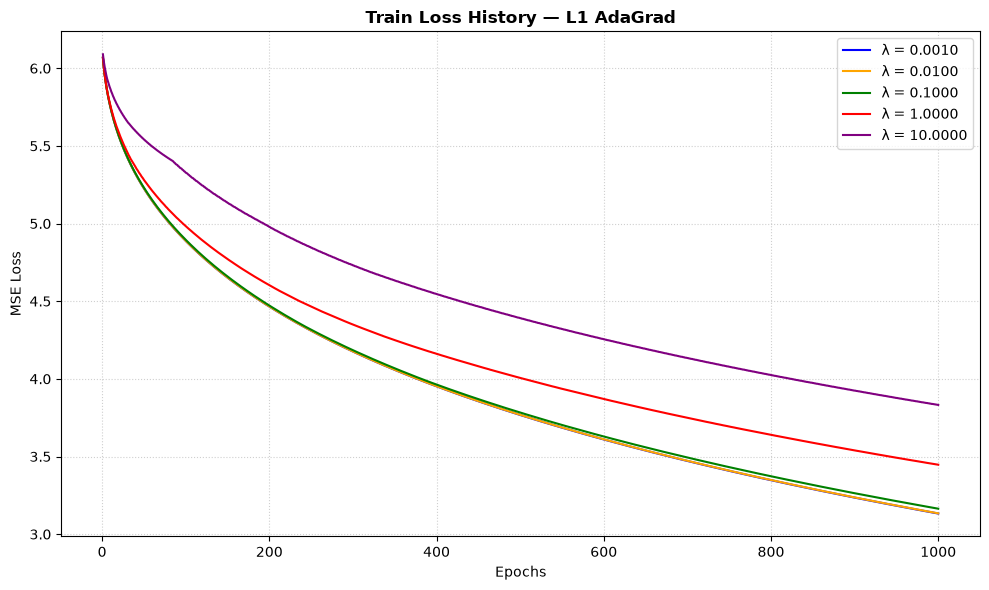

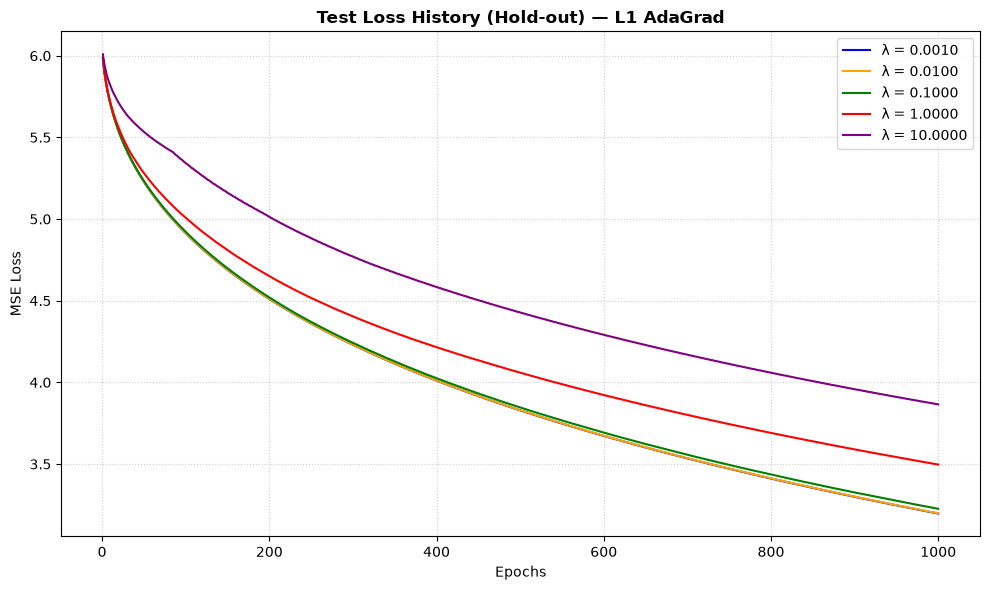

In [7]:
print("~~~~~~~~ТЕСТИРОВАНИЕ L1 ADAGRAD~~~~~~~~")
l1_adagrad_results = []
block_1_history = {}

for lmbda in lambdas:
    res = run_isolated_experiment(optimizer_name='AdaGrad', reg_type='L1', lmbda=lmbda)
    l1_adagrad_results.append(res)
    block_1_history[lmbda] = {'train_history': res['train_history'], 'test_history': res['test_history']}
    print(f"λ: {res['lambda']:.4f} | Train MSE: {res['final_train_loss']:.4f} | Test MSE: {res['test_loss']:.4f}")

best_l1_adagrad = min(l1_adagrad_results, key=lambda x: x['test_loss'])
print(f"Итог: Лучший λ = {best_l1_adagrad['lambda']:.4f} | Финальный Test MSE = {best_l1_adagrad['test_loss']:.4f}\n")
plot_epoch_histories(block_1_history, "L1 AdaGrad")

~~~~~~~~ТЕСТИРОВАНИЕ L2 ADAGRAD~~~~~~~~
λ: 0.0010 | Train MSE: 3.1328 | Test MSE: 3.1970
λ: 0.0100 | Train MSE: 3.1338 | Test MSE: 3.1980
λ: 0.1000 | Train MSE: 3.1443 | Test MSE: 3.2083
λ: 1.0000 | Train MSE: 3.2713 | Test MSE: 3.3314
λ: 10.0000 | Train MSE: 4.2282 | Test MSE: 4.2736
Итог: Лучший λ = 0.0010 | Финальный Test MSE = 3.1970



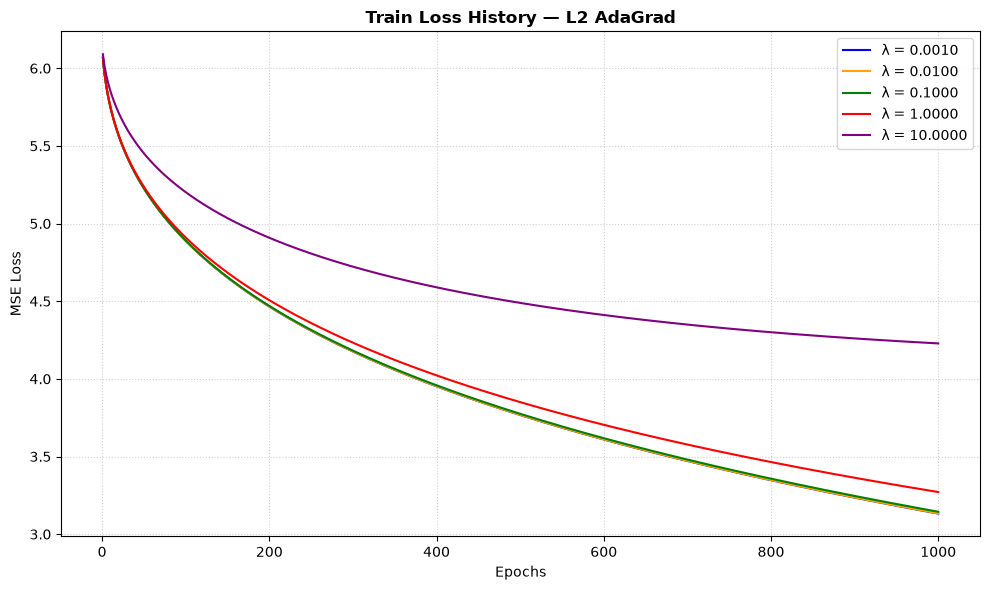

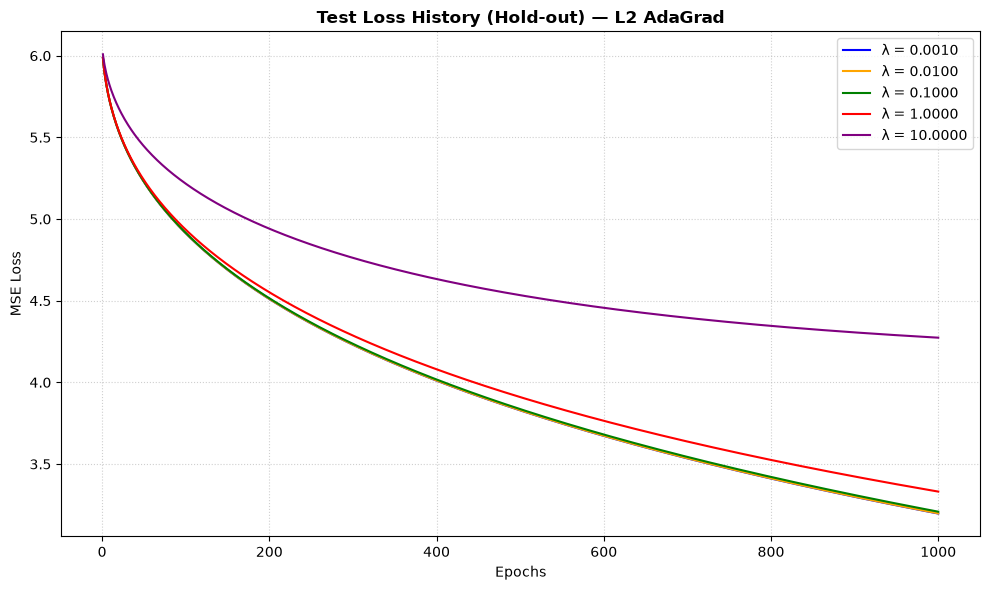

In [8]:
print("~~~~~~~~ТЕСТИРОВАНИЕ L2 ADAGRAD~~~~~~~~")
l2_adagrad_results = []
block_2_history = {}

for lmbda in lambdas:
    res = run_isolated_experiment(optimizer_name='AdaGrad', reg_type='L2', lmbda=lmbda)
    l2_adagrad_results.append(res)
    block_2_history[lmbda] = {'train_history': res['train_history'], 'test_history': res['test_history']}
    print(f"λ: {res['lambda']:.4f} | Train MSE: {res['final_train_loss']:.4f} | Test MSE: {res['test_loss']:.4f}")

best_l2_adagrad = min(l2_adagrad_results, key=lambda x: x['test_loss'])
print(f"Итог: Лучший λ = {best_l2_adagrad['lambda']:.4f} | Финальный Test MSE = {best_l2_adagrad['test_loss']:.4f}\n")

plot_epoch_histories(block_2_history, "L2 AdaGrad")


~~~~~~~~ТЕСТИРОВАНИЕ L1 ADAMW~~~~~~~~
λ: 0.0010 | Train MSE: 0.5187 | Test MSE: 0.5473
λ: 0.0100 | Train MSE: 0.5201 | Test MSE: 0.5484
λ: 0.1000 | Train MSE: 0.6018 | Test MSE: 0.6266
λ: 1.0000 | Train MSE: 0.9475 | Test MSE: 0.9648
λ: 10.0000 | Train MSE: 1.3306 | Test MSE: 1.3313
Итог: Лучший λ = 0.0010 | Финальный Test MSE = 0.5473



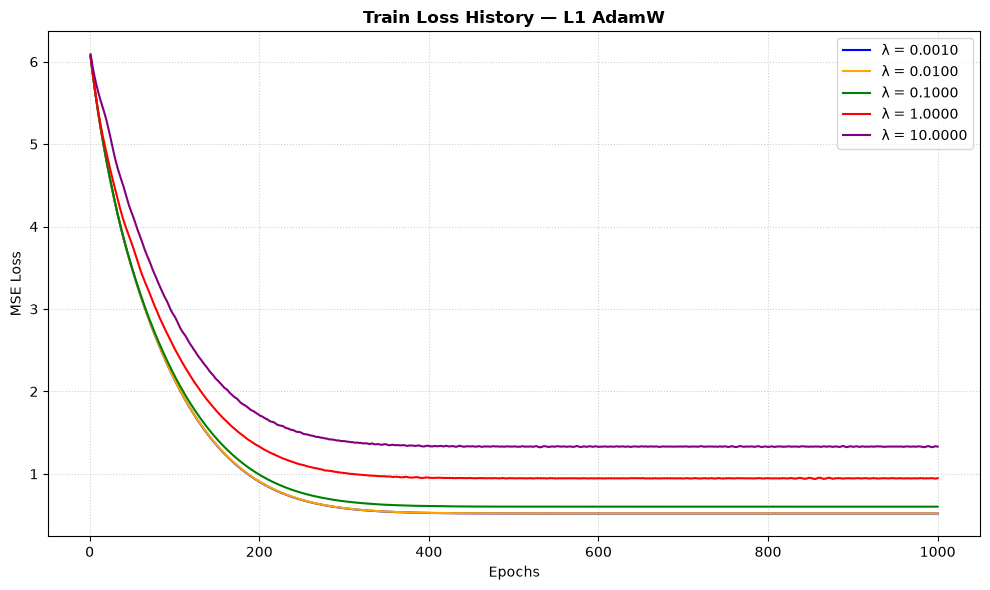

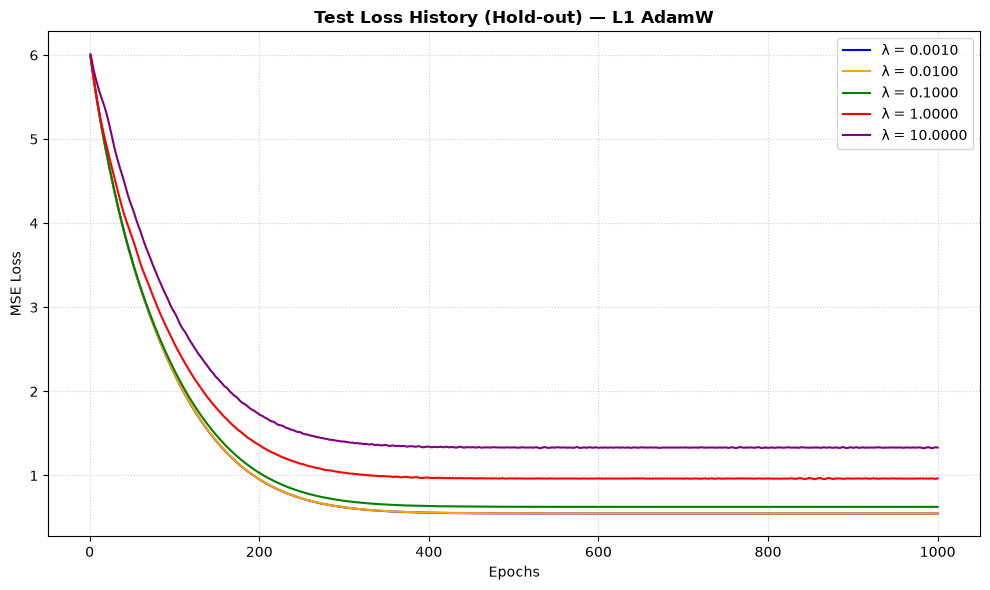

In [9]:
print("~~~~~~~~ТЕСТИРОВАНИЕ L1 ADAMW~~~~~~~~")
l1_adamw_results = []
block_3_history = {}

for lmbda in lambdas:
    res = run_isolated_experiment(optimizer_name='AdamW', reg_type='L1', lmbda=lmbda)
    l1_adamw_results.append(res)
    block_3_history[lmbda] = {'train_history': res['train_history'], 'test_history': res['test_history']}
    print(f"λ: {res['lambda']:.4f} | Train MSE: {res['final_train_loss']:.4f} | Test MSE: {res['test_loss']:.4f}")

best_l1_adamw = min(l1_adamw_results, key=lambda x: x['test_loss'])
print(f"Итог: Лучший λ = {best_l1_adamw['lambda']:.4f} | Финальный Test MSE = {best_l1_adamw['test_loss']:.4f}\n")

plot_epoch_histories(block_3_history, "L1 AdamW")


~~~~~~~~ТЕСТИРОВАНИЕ L2 ADAMW~~~~~~~~
λ: 0.0010 | Train MSE: 0.5187 | Test MSE: 0.5473
λ: 0.0100 | Train MSE: 0.5188 | Test MSE: 0.5478
λ: 0.1000 | Train MSE: 0.5310 | Test MSE: 0.5635
λ: 1.0000 | Train MSE: 1.8749 | Test MSE: 1.9375
λ: 10.0000 | Train MSE: 4.9580 | Test MSE: 5.0093
Итог: Лучший λ = 0.0010 | Финальный Test MSE = 0.5473



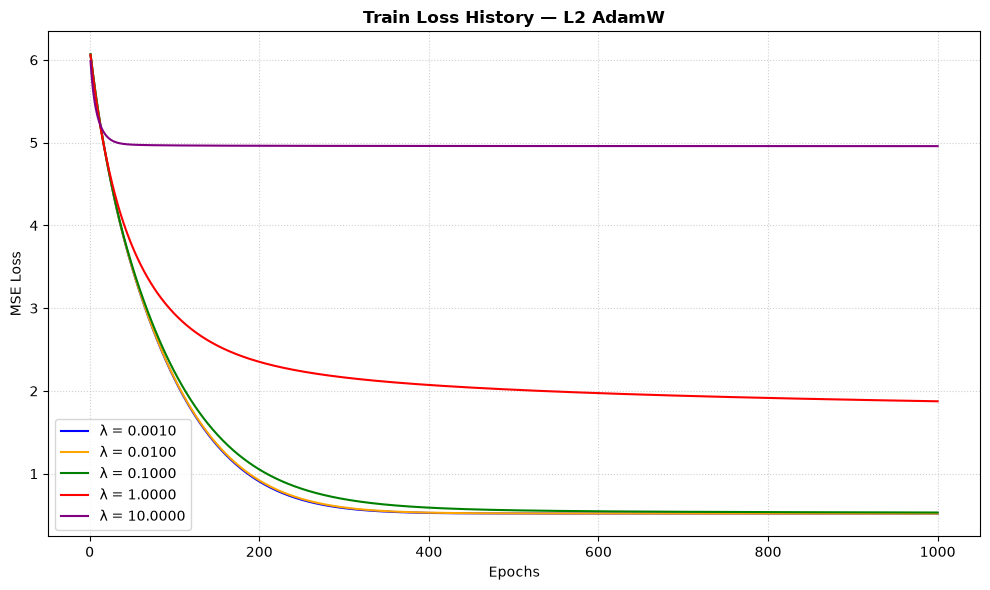

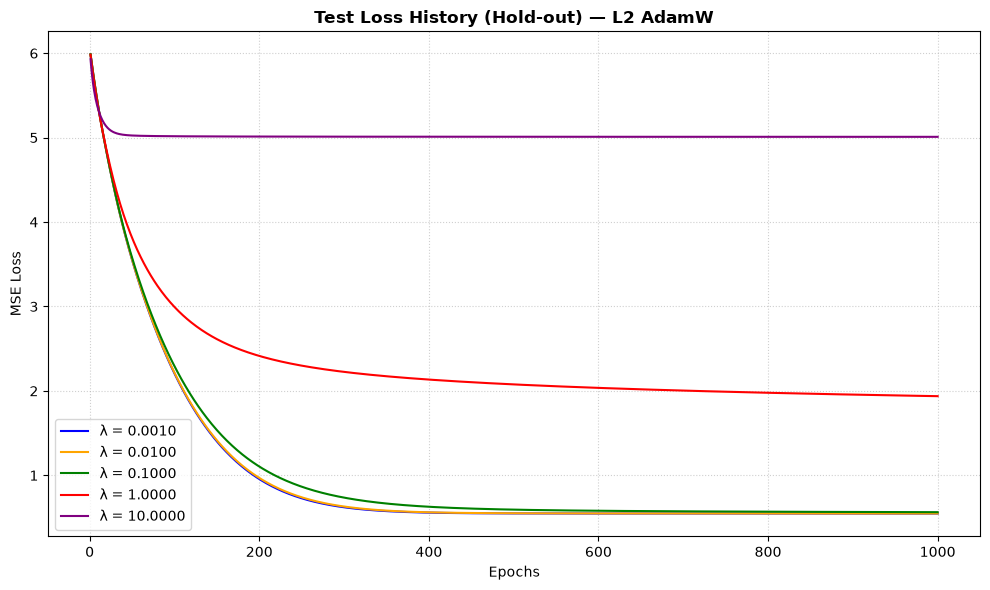

In [10]:
print("~~~~~~~~ТЕСТИРОВАНИЕ L2 ADAMW~~~~~~~~")
l2_adamw_results = []
block_4_history = {}

for lmbda in lambdas:
    res = run_isolated_experiment(optimizer_name='AdamW', reg_type='L2', lmbda=lmbda)
    l2_adamw_results.append(res)
    block_4_history[lmbda] = {'train_history': res['train_history'], 'test_history': res['test_history']}
    print(f"λ: {res['lambda']:.4f} | Train MSE: {res['final_train_loss']:.4f} | Test MSE: {res['test_loss']:.4f}")

best_l2_adamw = min(l2_adamw_results, key=lambda x: x['test_loss'])
print(f"Итог: Лучший λ = {best_l2_adamw['lambda']:.4f} | Финальный Test MSE = {best_l2_adamw['test_loss']:.4f}\n")

plot_epoch_histories(block_4_history, "L2 AdamW")


In [11]:
print("~~~~~~~~ИТОГОВОЕ СОПОСТАВЛЕНИЕ (условных) ПОБЕДИТЕЛЕЙ~~~~~~~~")
print(f"L1 AdaGrad Победитель (λ={best_l1_adagrad['lambda']:.4f}) | Финальный Test MSE: {best_l1_adagrad['test_loss']:.4f}")
print(f"L1 AdamW   Победитель (λ={best_l1_adamw['lambda']:.4f}) | Финальный Test MSE: {best_l1_adamw['test_loss']:.4f}")
print(f"L2 AdaGrad Победитель (λ={best_l2_adagrad['lambda']:.4f}) | Финальный Test MSE: {best_l2_adagrad['test_loss']:.4f}")
print(f"L2 AdamW   Победитель (λ={best_l2_adamw['lambda']:.4f}) | Финальный Test MSE: {best_l2_adamw['test_loss']:.4f}")

~~~~~~~~ИТОГОВОЕ СОПОСТАВЛЕНИЕ (условных) ПОБЕДИТЕЛЕЙ~~~~~~~~
L1 AdaGrad Победитель (λ=0.0010) | Финальный Test MSE: 3.1970
L1 AdamW   Победитель (λ=0.0010) | Финальный Test MSE: 0.5473
L2 AdaGrad Победитель (λ=0.0010) | Финальный Test MSE: 3.1970
L2 AdamW   Победитель (λ=0.0010) | Финальный Test MSE: 0.5473
